# Tech Challenge 3 - Big Data & Analytics
## State of Data Brasil (2023, 2024 e 2025)

Este notebook analisa as três edições mais recentes da pesquisa State of Data Brasil, realizada por Data Hackers e Bain.

O objetivo é reunir os dados dos três anos e responder às seguintes perguntas:

1. Como está estruturado o mercado brasileiro de Dados?
2. Quais perfis profissionais são mais valorizados pelo mercado?
3. Como está a diversidade de gênero nas carreiras de Dados?
4. Quais tecnologias apresentam maior adoção entre os profissionais?
5. Qual é o nível de adoção de Inteligência Artificial e qual é o seu impacto?
6. Existem diferenças entre regiões, níveis de senioridade ou modelos de trabalho?
7. Quais oportunidades e desafios existem para empresas que desejam investir em Dados e Inteligência Artificial?

A limpeza e a padronização realizadas aqui também são utilizadas nos scripts da pasta `src`.

Neste notebook, o processo é feito com pandas para facilitar a análise local dos dados.

In [ ]:
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import textwrap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

# Paleta de cores usada nos gráficos.
COR_DESTAQUE = "#5C2F7C"    # Cor usada para destacar um dado importante.
COR_COMPARACAO = "#A5114EE5"  # Cor principal para a série mais recente.
COR_SEC_1 = "#667985"
COR_SEC_2 = "#8D9AA1"
COR_SEC_3 = "#B3BBBF"

COR_SEQUENCIAL = COR_COMPARACAO
PALETA_CATEGORICA = [COR_COMPARACAO, COR_SEC_1, COR_SEC_2, COR_SEC_3, COR_DESTAQUE]
TINTA_PRIMARIA = "#161616"
TINTA_SECUNDARIA = "#4A4A47"
TINTA_MUTED = "#6F6E69"
GRADE = "#E1E0D9"
SUPERFICIE = "#FCFCFB"

# Configurações de estilo do matplotlib.
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "axes.edgecolor": GRADE,
    "axes.labelcolor": TINTA_SECUNDARIA,
    "axes.titlecolor": TINTA_PRIMARIA,
    "text.color": TINTA_PRIMARIA,
    "xtick.color": TINTA_MUTED,
    "ytick.color": TINTA_MUTED,
    "grid.color": GRADE,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "figure.dpi": 110,
})

ANOS = [2023, 2024, 2025]

# Usa cinza nos anos antigos e a cor principal no ano mais recente.
COR_POR_ANO = {2023: COR_SEC_3, 2024: COR_SEC_2, 2025: COR_COMPARACAO}

## 1. Carregamento das tabelas

Cada ano da pesquisa está em um arquivo CSV diferente. Primeiro, cada arquivo é carregado em uma tabela separada. Isso facilita verificar e limpar cada base antes de uni-las.

O encoding utilizado é UTF-8, que mantém corretamente os acentos dos textos.

In [2]:
BASE_DATA = "../data"

df_2023 = pd.read_csv(f"{BASE_DATA}/dataset-2023-2024.csv", low_memory=False, encoding="utf-8", on_bad_lines="skip")
df_2024 = pd.read_csv(f"{BASE_DATA}/dataset-2024-2025.csv", low_memory=False, encoding="utf-8", on_bad_lines="skip")
df_2025 = pd.read_csv(f"{BASE_DATA}/dataset-2025-2026.csv", low_memory=False, encoding="utf-8", on_bad_lines="skip")

for ano, tabela in [(2023, df_2023), (2024, df_2024), (2025, df_2025)]:
    print(f"{ano}: {tabela.shape[0]} linhas x {tabela.shape[1]} colunas")

2023: 5293 linhas x 399 colunas
2024: 5217 linhas x 403 colunas
2025: 3495 linhas x 388 colunas


## 2. Limpeza dos dados

Antes da análise, as tabelas passam por uma limpeza básica:

- Remoção de linhas totalmente vazias.
- Remoção de registros duplicados.
- Retirada de espaços extras nos textos.
- Troca de textos vazios por valores nulos.
- Correção de duas faixas salariais que apresentavam erro de digitação.

Depois dessa etapa, as tabelas limpas são utilizadas nas próximas partes do notebook.

In [ ]:
# Limpeza dos dados brutos
def limpar_bruto(df, ano):
    # Remove linhas vazias, duplicadas e espaços extras nos textos.
    n_inicial = len(df)

    df = df.dropna(how="all")
    n_pos_vazias = len(df)

    df = df.drop_duplicates()
    n_pos_dup = len(df)

    colunas_texto = df.select_dtypes(include=["object", "string"]).columns
    for c in colunas_texto:
        df[c] = df[c].astype("string").str.strip()
        df[c] = df[c].replace("", pd.NA)

    df = df.reset_index(drop=True)

    print(f"[{ano}] linhas: {n_inicial} -> {n_pos_vazias} (sem vazias) -> {n_pos_dup} (sem duplicata)")
    return df

# Limpa os três dataframes.
df_2023 = limpar_bruto(df_2023, 2023)
df_2024 = limpar_bruto(df_2024, 2024)
df_2025 = limpar_bruto(df_2025, 2025)

# Corrige duas faixas salariais que tinham erro de digitação.
CORRECOES_FAIXA_SALARIAL = {
    "de R$ 101/mês a R$ 2.000/mês": "de R$ 1.001/mês a R$ 2.000/mês",
    "de R$ 25.001/mês a R$ 3000/mês": "de R$ 25.001/mês a R$ 30.000/mês",
}

[2023] linhas: 5293 -> 5293 (sem vazias) -> 5293 (sem duplicata)


[2024] linhas: 5217 -> 5217 (sem vazias) -> 5215 (sem duplicata)


[2025] linhas: 3495 -> 3495 (sem vazias) -> 3494 (sem duplicata)


## 3. União dos três anos

Os nomes das colunas mudaram entre as edições da pesquisa. Por exemplo, uma pergunta pode aparecer como `P2_g` em 2023 e como `2.g_nivel` em 2024.

Para resolver essa diferença, o código identifica apenas o código da pergunta e cria nomes padronizados. Assim, as respostas dos três anos podem ser reunidas em uma única tabela.

Os códigos utilizados foram conferidos nos arquivos de cabeçalho de cada ano.

In [ ]:
# Corrige os nomes das colunas que mudaram de um ano para outro.
DOTTED_RE = re.compile(r"^(\d+(?:\.[A-Za-z0-9]+)*)[_ ](.*)$")

# Normaliza o código da pergunta, que pode aparecer em formatos diferentes nos anos.
def normaliza_codigo(col):
    # Extrai o código da pergunta, mesmo com os formatos diferentes dos anos.
    col = col.strip()
    # Em 2023, o nome vem como uma tupla de texto.
    try:
        tupla = ast.literal_eval(col)
        if isinstance(tupla, tuple) and len(tupla) >= 1:
            codigo = str(tupla[0]).strip()
            if codigo.upper().startswith("P"):
                codigo = codigo[1:]
            return codigo.replace("_", ".").lower()
    except Exception:
        pass
    # Em 2024 e 2025, o código aparece no início do nome da coluna.
    m = DOTTED_RE.match(col)
    if m:
        return m.group(1).lower()
    return col.lower()

# Cria um mapa entre o código da pergunta e o nome da coluna.
def monta_mapa_codigos(df):
    # Cria um mapa entre o código da pergunta e o nome da coluna.
    mapa = {}
    for c in df.columns:
        mapa.setdefault(normaliza_codigo(c), c)
    return mapa

# Cria mapas de códigos para cada ano.
def pega(df, mapa, codigo):
    # Retorna a coluna do código ou uma coluna vazia quando ela não existe.
    col = mapa.get(codigo) if codigo else None
    return df[col] if col is not None else pd.Series(np.nan, index=df.index)

# Converte respostas 0 e 1 para Sim e Nao. Nos dados brutos, cada opção de pergunta de múltipla escolha vem em sua própria coluna: 0 quando o
# respondente viu a pergunta e não marcou aquela opção, e vazio (NaN) quando o respondente não chegou a ver a pergunta (pergunta condicional
# ou não aplicável naquele ano). Por isso, valor ausente vira "N/I" (não informado), e não "Nao" — ver observação metodológica logo abaixo
# e a função pct_sim(), usada em todos os percentuais deste notebook.
def binario(df, mapa, codigo):
    if not codigo:
        return pd.Series("N/I", index=df.index)
    s = pega(df, mapa, codigo)
    out = pd.Series("N/I", index=df.index, dtype="object")
    out[s == 1] = "Sim"
    out[s == 0] = "Nao"
    return out

# Junta várias colunas e considera Sim quando alguma delas tem valor 1.
# Segue a mesma convenção de N/I da função binario() acima.
def binario_or(df, mapa, codigos):
    if not codigos:
        return pd.Series("N/I", index=df.index)
    acc = pd.Series(np.nan, index=df.index)
    for codigo in codigos:
        s = pega(df, mapa, codigo)
        acc = np.where(s == 1, 1, np.where(acc == 1, 1, np.where(s == 0, 0, acc)))
        acc = pd.Series(acc, index=df.index)
    out = pd.Series("N/I", index=df.index, dtype="object")
    out[acc == 1] = "Sim"
    out[acc == 0] = "Nao"
    return out

### Observação metodológica sobre perguntas binárias e condicionais

Várias perguntas da pesquisa (tecnologias utilizadas, formas de uso pessoal de IA Generativa, motivos para não usar IA Generativa, impacto da IA no negócio) são de múltipla escolha ou são perguntas condicionais, exibidas apenas a quem respondeu de determinada forma a uma pergunta anterior. Nos dados brutos, cada opção vem como uma coluna própria: `0` quando o respondente viu a pergunta e não marcou aquela opção, e vazio (`NaN`) quando o respondente não chegou a ver essa pergunta.

A função `binario()` (acima) mapeia `1` para `"Sim"`, `0` para `"Nao"` e o valor ausente para `"N/I"` (não informado/não aplicável). Como `"N/I"` não é uma resposta negativa, ele **não deve entrar no denominador** ao calcular o percentual de "Sim" — contá-lo junto com "Nao" transformaria ausência de resposta em uma resposta negativa, distorcendo os percentuais para baixo. Por isso, todas as análises de perguntas binárias deste notebook usam a função `pct_sim()` (definida na seção de funções auxiliares, mais adiante), que calcula o percentual apenas sobre as respostas válidas (`Sim`/`Nao`).

Quando uma pergunta não existiu em determinado ano (por exemplo, Java e JavaScript não foram perguntados em 2025, e os motivos para não usar IA Generativa só foram perguntados em 2025), a coluna correspondente fica inteiramente `N/I` naquele ano — o texto de cada seção indica quando isso ocorre.

In [ ]:
# Define os códigos das perguntas de resposta única em cada ano.
CAMPOS_SIMPLES = {
    "genero": {2023: "1.b", 2024: "1.b", 2025: "1.b"},
    "cor_raca": {2023: "1.c", 2024: "1.c", 2025: "1.c"},
    "regiao": {2023: "1.i.2", 2024: "1.i.2", 2025: "1.i.2"},
    "uf": {2023: "1.i.1", 2024: "1.i.1", 2025: "1.i.1"},
    "nivel_ensino": {2023: "1.l", 2024: "1.l", 2025: "1.l"},
    "situacao_trabalho": {2023: "2.a", 2024: "2.a", 2025: "2.a"},
    "setor": {2023: "2.b", 2024: "2.b", 2025: "2.b"},
    "cargo": {2023: "2.f", 2024: "2.f", 2025: "2.f"},
    "senioridade": {2023: "2.g", 2024: "2.g", 2025: "2.g"},
    "faixa_salarial": {2023: "2.h", 2024: "2.h", 2025: "2.h"},
    # A pergunta sobre o modelo de trabalho mudou em 2025.
    "modelo_trabalho": {2023: "2.r", 2024: "2.r", 2025: "2.q"},
    "numero_pessoas_dados": {2023: "3.a", 2024: "3.a", 2025: "3.a"},
    "ia_prioridade": {2023: "3.e", 2024: "3.e", 2025: "3.e"},
}

# Define os códigos das tecnologias, que são respostas 0 ou 1.
CAMPOS_BINARIOS = {
    # Linguagens de programação.
    "usa_python": {2023: "4.d.3", 2024: "4.d.3", 2025: "4.c.3"},
    "usa_sql": {2023: "4.d.1", 2024: "4.d.1", 2025: "4.c.1"},
    "usa_r": {2023: "4.d.2", 2024: "4.d.2", 2025: "4.c.2"},
    "usa_java": {2023: "4.d.6", 2024: "4.d.6", 2025: None},
    "usa_javascript": {2023: "4.d.14", 2024: "4.d.14", 2025: None},
    "usa_scala": {2023: "4.d.10", 2024: "4.d.10", 2025: "4.c.7"},
    "usa_julia": {2023: "4.d.7", 2024: "4.d.7", 2025: "4.c.5"},
    "usa_rust": {2023: "4.d.12", 2024: "4.d.12", 2025: "4.c.9"},
    "usa_vba": {2023: "4.d.9", 2024: "4.d.9", 2025: "4.c.6"},
    "usa_dax": {2023: None, 2024: None, 2025: "4.c.8"},
    # Bancos de dados.
    "usa_mysql": {2023: "4.g.1", 2024: "4.g.1", 2025: "4.d.1"},
    "usa_postgresql": {2023: "4.g.12", 2024: "4.g.12", 2025: "4.d.12"},
    "usa_mongodb": {2023: "4.g.8", 2024: "4.g.8", 2025: "4.d.8"},
    "usa_bigquery": {2023: "4.g.22", 2024: "4.g.22", 2025: "4.d.22"},
    "usa_redshift": {2023: "4.g.24", 2024: "4.g.24", 2025: "4.d.24"},
    "usa_athena": {2023: "4.g.25", 2024: "4.g.25", 2025: "4.d.25"},
    "usa_snowflake": {2023: "4.g.26", 2024: "4.g.26", 2025: "4.d.26"},
    "usa_s3": {2023: "4.g.11", 2024: "4.g.11", 2025: "4.d.11"},
    # Serviços de nuvem.
    "usa_aws": {2023: "4.h.2", 2024: "4.h.1", 2025: "4.e.1"},
    "usa_gcp": {2023: "4.h.3", 2024: "4.h.2", 2025: "4.e.2"},
    "usa_azure": {2023: "4.h.1", 2024: "4.h.3", 2025: "4.e.3"},
    # Ferramentas de BI.
    "usa_powerbi": {2023: "4.j.1", 2024: "4.j.1", 2025: "4.g.1"},
    "usa_qlik": {2023: "4.j.2", 2024: "4.j.2", 2025: "4.g.2"},
    "usa_tableau": {2023: "4.j.3", 2024: "4.j.3", 2025: "4.g.3"},
    "usa_metabase": {2023: "4.j.4", 2024: "4.j.4", 2025: "4.g.4"},
    "usa_looker": {2023: "4.j.7", 2024: "4.j.7", 2025: "4.g.7"},
    "usa_grafana": {2023: "4.j.19", 2024: "4.j.15", 2025: "4.g.15"},
}

# Junta tecnologias que aparecem em mais de uma pergunta.
CAMPOS_BINARIOS_OR = {
    "usa_airflow": {a: ["6.b.3", "7.b.3"] for a in ANOS},
    "usa_glue": {a: ["6.b.6", "7.b.6"] for a in ANOS},
    "usa_fivetran": {a: ["6.b.11", "7.b.11"] for a in ANOS},
    "usa_stitch": {a: ["6.b.10", "7.b.10"] for a in ANOS},
    "usa_nifi": {a: ["6.b.4", "7.b.4"] for a in ANOS},
    "usa_talend": {a: ["6.b.7", "7.b.7"] for a in ANOS},
    "usa_pentaho": {
        2023: ["6.b.8", "7.b.8", "4.j.21"],
        2024: ["6.b.8", "7.b.8", "4.j.16"],
        2025: ["6.b.8", "7.b.8", "4.g.16"],
    },
    "usa_databricks": {
        2023: ["4.g.27", "6.b.20", "7.b.20"],
        2024: ["4.g.27", "6.b.20", "7.b.20"],
        2025: ["4.d.27", "6.b.20", "7.b.20"],
    },
}

# Define os tipos de uso de IA generativa nas empresas.
IA_TIPO_USO = {
    "ia_uso_independente": "3.f.1",
    "ia_uso_direcionamento_centralizado": "3.f.2",
    "ia_uso_devs_copilots": "3.f.3",
    "ia_uso_produtos_externos": "3.f.4",
    "ia_uso_produtos_internos": "3.f.5",
    "ia_uso_principal_frente_negocio": "3.f.6",
    "ia_uso_nao_e_prioridade": "3.f.7",
    "ia_uso_nao_sei_opinar": "3.f.8",
}

# Define os motivos para não usar IA generativa.
IA_MOTIVO_NAO_USO = {
    "ia_motivo_falta_compreensao": "1",
    "ia_motivo_falta_confiabilidade": "2",
    "ia_motivo_incerteza_regulacao": "3",
    "ia_motivo_seguranca_privacidade": "4",
    "ia_motivo_roi_nao_comprovado": "5",
    "ia_motivo_dados_nao_prontos": "6",
    "ia_motivo_falta_expertise": "7",
    "ia_motivo_alta_direcao_nao_ve_valor": "8",
    "ia_motivo_propriedade_intelectual": "9",
}
LETRA_MOTIVO_IA = {2023: "g", 2024: "g", 2025: "h"}

# Define as opções de uso pessoal de IA no trabalho.
IA_USO_PESSOAL_SUB = {
    "ia_pessoal_nao_uso": "1",
    "ia_pessoal_uso_gratuito": "2",
    "ia_pessoal_uso_pago_proprio": "3",
    "ia_pessoal_empresa_paga": "4",
    "ia_pessoal_uso_copilot": "5",
}
LETRA_USO_PESSOAL_IA = {2023: "m", 2024: "m", 2025: "j"}

# Função para harmonizar os dados de um ano específico.
def harmonizar_ano(ano, df_limpo):
    # Monta uma tabela com os mesmos nomes de coluna para cada ano.
    mapa = monta_mapa_codigos(df_limpo)
    out = pd.DataFrame(index=df_limpo.index)
    out["ano_pesquisa"] = ano

    for campo, codigos in CAMPOS_SIMPLES.items():
        out[campo] = pega(df_limpo, mapa, codigos.get(ano))

    out["faixa_salarial"] = out["faixa_salarial"].replace(CORRECOES_FAIXA_SALARIAL)

    for campo, codigos in CAMPOS_BINARIOS.items():
        out[campo] = binario(df_limpo, mapa, codigos.get(ano))

    for campo, codigos in CAMPOS_BINARIOS_OR.items():
        out[campo] = binario_or(df_limpo, mapa, codigos.get(ano) or [])

    for campo, sufixo in IA_TIPO_USO.items():
        out[campo] = binario(df_limpo, mapa, sufixo)

    letra_motivo = LETRA_MOTIVO_IA[ano]
    for campo, sufixo in IA_MOTIVO_NAO_USO.items():
        out[campo] = binario(df_limpo, mapa, f"3.{letra_motivo}.{sufixo}")

    letra_pessoal = LETRA_USO_PESSOAL_IA[ano]
    for campo, sufixo in IA_USO_PESSOAL_SUB.items():
        out[campo] = binario(df_limpo, mapa, f"4.{letra_pessoal}.{sufixo}")

    return out

# Harmoniza os dados de cada ano e junta em um único dataframe.
df_harm_2023 = harmonizar_ano(2023, df_2023)
df_harm_2024 = harmonizar_ano(2024, df_2024)
df_harm_2025 = harmonizar_ano(2025, df_2025)

# Junta os três dataframes harmonizados em um único dataframe.
df = pd.concat([df_harm_2023, df_harm_2024, df_harm_2025], ignore_index=True)

print(f"total de linhas depois de juntar: {len(df)}")
print(df["ano_pesquisa"].value_counts().sort_index())

total de linhas depois de juntar: 14002
ano_pesquisa
2023    5293
2024    5215
2025    3494
Name: count, dtype: int64


### Tratamento das faixas ordinais

As colunas `faixa_salarial` e `numero_pessoas_dados` possuem respostas em intervalos de valores.

Para permitir comparações numéricas, cada intervalo é substituído por um ponto médio. Também é definida uma ordem para que as categorias apareçam corretamente nos gráficos.

In [ ]:
# Define a ordem das faixas salariais e seus pontos médios.
FAIXAS_SALARIAIS_ORDEM = [
    "Menos de R$ 1.000/mês",
    "de R$ 1.001/mês a R$ 2.000/mês",
    "de R$ 2.001/mês a R$ 3.000/mês",
    "de R$ 3.001/mês a R$ 4.000/mês",
    "de R$ 4.001/mês a R$ 6.000/mês",
    "de R$ 6.001/mês a R$ 8.000/mês",
    "de R$ 8.001/mês a R$ 12.000/mês",
    "de R$ 12.001/mês a R$ 16.000/mês",
    "de R$ 16.001/mês a R$ 20.000/mês",
    "de R$ 20.001/mês a R$ 25.000/mês",
    "de R$ 25.001/mês a R$ 30.000/mês",
    "de R$ 30.001/mês a R$ 40.000/mês",
    "Acima de R$ 40.001/mês",
]
# Define o ponto médio de cada faixa salarial, para poder calcular médias ponderadas.
FAIXAS_SALARIAIS_PONTO_MEDIO = {
    "Menos de R$ 1.000/mês": 500,
    "de R$ 1.001/mês a R$ 2.000/mês": 1500,
    "de R$ 2.001/mês a R$ 3.000/mês": 2500,
    "de R$ 3.001/mês a R$ 4.000/mês": 3500,
    "de R$ 4.001/mês a R$ 6.000/mês": 5000,
    "de R$ 6.001/mês a R$ 8.000/mês": 7000,
    "de R$ 8.001/mês a R$ 12.000/mês": 10000,
    "de R$ 12.001/mês a R$ 16.000/mês": 14000,
    "de R$ 16.001/mês a R$ 20.000/mês": 18000,
    "de R$ 20.001/mês a R$ 25.000/mês": 22500,
    "de R$ 25.001/mês a R$ 30.000/mês": 27500,
    "de R$ 30.001/mês a R$ 40.000/mês": 35000,
    "Acima de R$ 40.001/mês": 45000,
}

# Transforma cada faixa salarial no seu ponto médio.
df["salario_ponto_medio"] = df["faixa_salarial"].map(FAIXAS_SALARIAIS_PONTO_MEDIO)

NUM_PESSOAS_ORDEM = [
    "Ainda não temos pessoas atuando com dados na empresa",
    "1 - 3", "4 - 10", "11 - 20", "21 - 50", "51 - 100", "101 - 300",
    "Acima de 300 pessoas",
]
NUM_PESSOAS_PONTO_MEDIO = {
    "Ainda não temos pessoas atuando com dados na empresa": 0,
    "1 - 3": 2, "4 - 10": 7, "11 - 20": 15, "21 - 50": 35,
    "51 - 100": 75, "101 - 300": 200, "Acima de 300 pessoas": 350,
}

# Transforma cada faixa de tamanho de equipe no seu ponto médio.
df["tamanho_time_ponto_medio"] = df["numero_pessoas_dados"].map(NUM_PESSOAS_PONTO_MEDIO)

SENIORIDADE_ORDEM = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]

# Funções para plotar gráficos.
def barh_serie_unica(serie, titulo, xlabel, ax=None, cor=COR_SEQUENCIAL, fmt="{:.0f}"):
    # Cria um gráfico de barras horizontais com os valores escritos.
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(2.5, 0.42 * len(serie))))
    serie = serie.sort_values()
    barras = ax.barh(serie.index.astype(str), serie.values, color=cor, height=0.62)
    ax.set_title(titulo, loc="left", pad=12)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    xmax = serie.values.max()
    ax.set_xlim(0, xmax * 1.18)
    for barra, valor in zip(barras, serie.values):
        ax.text(barra.get_width() + xmax * 0.015, barra.get_y() + barra.get_height() / 2,
                fmt.format(valor), va="center", ha="left", fontsize=9.5, color=TINTA_SECUNDARIA)
    return ax

# Calcula o percentual de cada categoria dentro de cada ano.
def pct_por_categoria(data, coluna):
    # Calcula o percentual de cada categoria dentro de cada ano.
    contagem = data.groupby(["ano_pesquisa", coluna]).size().rename("n").reset_index()
    total_ano = data.groupby("ano_pesquisa").size().rename("total")
    contagem = contagem.merge(total_ano, on="ano_pesquisa")
    contagem["pct"] = contagem["n"] / contagem["total"] * 100
    return contagem

# Percentual de "Sim" sobre as respostas válidas (Sim/Nao) de uma pergunta binária, excluindo o "N/I" do denominador (ver observação metodológica
# logo após a definição de binario()). Usada em todas as perguntas de tecnologia e de IA deste notebook.
def pct_sim(serie):
    validos = serie.isin(["Sim", "Nao"])
    if not validos.any():
        return np.nan
    return (serie[validos] == "Sim").mean() * 100

# Aplica pct_sim a cada coluna de um DataFrame de perguntas binárias.
def pct_sim_colunas(df_binario):
    return df_binario.apply(pct_sim)

print("Tudo pronto, agora é só plotar")

Tudo pronto, agora é só plotar


---
## Pergunta 1 - Como está estruturado o mercado brasileiro de Dados?

Nesta etapa, são analisados o setor de atuação, a senioridade dos profissionais e o tamanho das equipes de Dados. Os resultados são comparados entre 2023 e 2025.

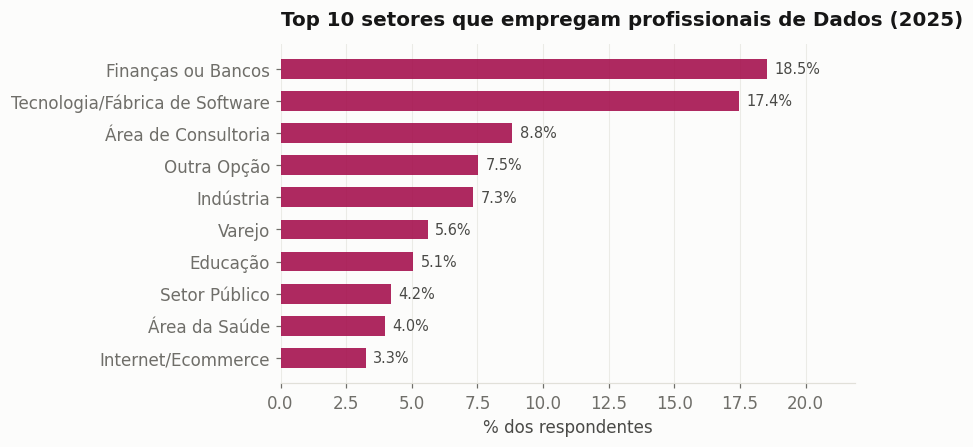

In [7]:
# Exemplo de gráfico: Top 10 setores que empregam profissionais de Dados em 2025.
df_2025_h = df[df["ano_pesquisa"] == 2025]

# Calcula o percentual de cada setor em 2025 e plota os 10 mais frequentes.
top_setores = df_2025_h["setor"].value_counts(normalize=True).mul(100).head(10)
barh_serie_unica(top_setores, "Top 10 setores que empregam profissionais de Dados (2025)", "% dos respondentes", fmt="{:.1f}%")

plt.tight_layout()
plt.show()

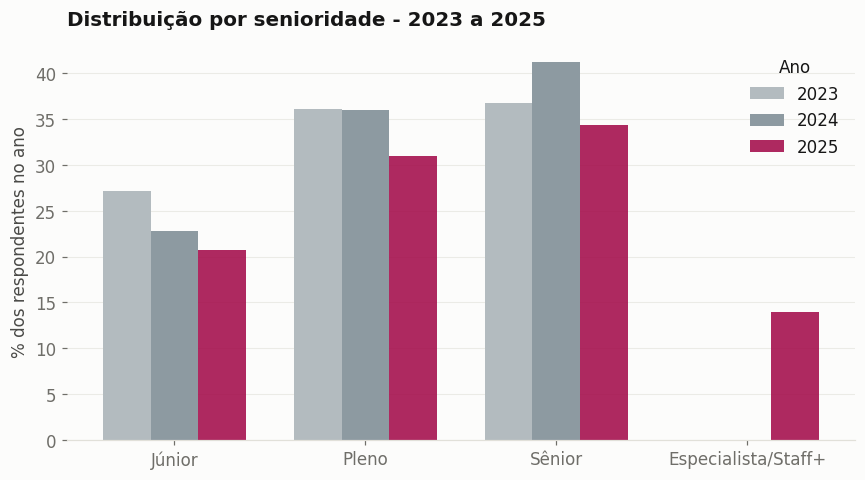

In [ ]:
# Exemplo de gráfico: Distribuição por senioridade nos anos de 2023 a 2025.
senioridade_ano = pct_por_categoria(df.dropna(subset=["senioridade"]), "senioridade")
ordem_presente = [s for s in SENIORIDADE_ORDEM if s in senioridade_ano["senioridade"].unique()]

# Plota a distribuição por senioridade nos anos de 2023 a 2025.
fig, ax = plt.subplots(figsize=(8, 4.5))
largura = 0.25
x = np.arange(len(ordem_presente))
for i, ano in enumerate(ANOS):
    valores = [senioridade_ano.query("ano_pesquisa == @ano and senioridade == @s")["pct"].sum() for s in ordem_presente]
    ax.bar(x + (i - 1) * largura, valores, width=largura, label=str(ano), color=COR_POR_ANO[ano])

# Configurações do gráfico.
ax.set_xticks(x, ordem_presente)
ax.set_ylabel("% dos respondentes no ano")
ax.set_title("Distribuição por senioridade - 2023 a 2025", loc="left", pad=12)
ax.grid(axis="y", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(title="Ano", frameon=False)

plt.tight_layout()
plt.show()

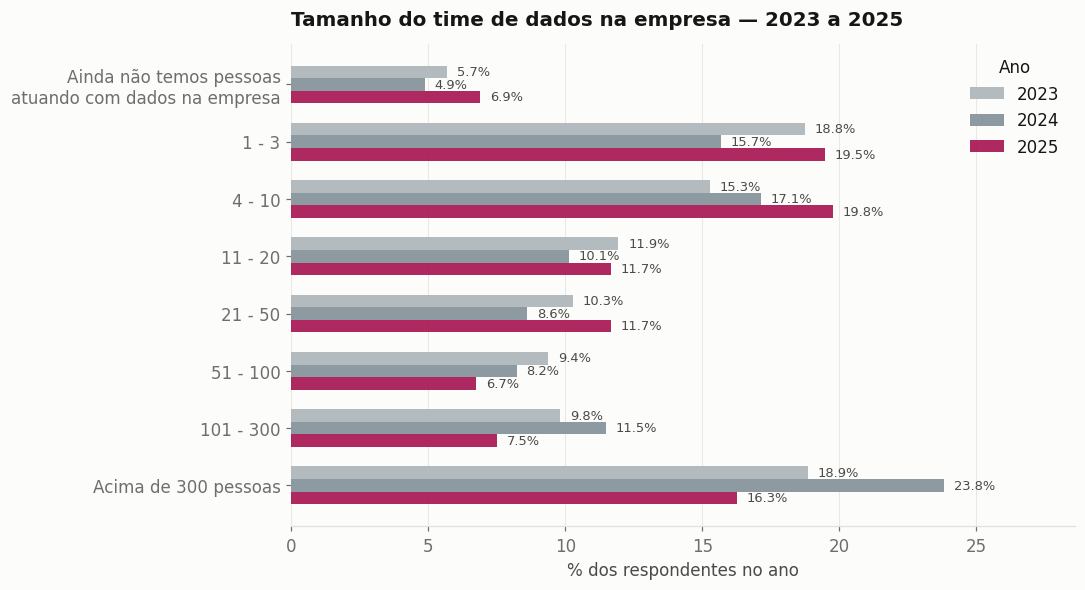

In [ ]:
# Tamanho do time de dados na empresa - 2023 a 2025
time_ano = pct_por_categoria(
    df.dropna(subset=["numero_pessoas_dados"]),
    "numero_pessoas_dados"
)

ordem_presente = [
    t for t in NUM_PESSOAS_ORDEM
    if t in time_ano["numero_pessoas_dados"].unique()
]

fig, ax = plt.subplots(figsize=(10, 5.5))

altura = 0.22
y = np.arange(len(ordem_presente))

for i, ano in enumerate(ANOS):
    valores = [
        time_ano.query(
            "ano_pesquisa == @ano and numero_pessoas_dados == @t"
        )["pct"].sum()
        for t in ordem_presente
    ]

    barras = ax.barh(
        y + (i - 1) * altura,
        valores,
        height=altura,
        label=str(ano),
        color=COR_POR_ANO[ano]
    )

    # Valor ao final de cada barra
    for barra, valor in zip(barras, valores):
        ax.text(
            valor + 0.35,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=8.5,
            color=TINTA_SECUNDARIA
        )

# Categorias
ax.set_yticks(y)
ax.set_yticklabels(ordem_presente)

# Primeira categoria no topo
ax.invert_yaxis()

# Eixos
ax.set_xlabel("% dos respondentes no ano")
ax.set_ylabel("")

# Título
ax.set_title(
    "Tamanho do time de dados na empresa — 2023 a 2025",
    loc="left",
    pad=12
)

# Grade
ax.grid(
    axis="x",
    color=GRADE,
    linewidth=0.7,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    colors=TINTA_MUTED
)

# Espaço para os valores no fim das barras
maior_valor = time_ano["pct"].max()

ax.set_xlim(
    0,
    maior_valor * 1.20
)

# Legenda dentro do gráfico
ax.legend(
    title="Ano",
    frameon=False,
    loc="upper right",
    labelspacing=0.5
)

# Rótulo da primeira categoria com quebra
rotulos = [
    "Ainda não temos pessoas\natuando com dados na empresa"
    if t == "Ainda não temos pessoas atuando com dados na empresa"
    else t
    for t in ordem_presente
]

ax.set_yticklabels(rotulos)

plt.tight_layout()
plt.show()

O mercado de Dados está concentrado principalmente nos setores de Finanças/Bancos e Tecnologia, que juntos respondem por cerca de um terço dos respondentes de 2025. A distribuição por senioridade muda pouco entre os anos, com maior presença de profissionais Plenos e Sêniores.

O tamanho das equipes de Dados é bastante diverso: nenhuma faixa reúne a maioria dos respondentes, e as equipes de até 10 pessoas somam entre 33% e 39% da amostra, a depender do ano. A participação de equipes grandes (acima de 300 pessoas) também não cresce de forma constante — foi de 18,9% em 2023 para 23,8% em 2024 e caiu para 16,3% em 2025 —, então não há, nesta amostra, evidência de uma tendência linear de expansão das equipes maiores.

---
## Pergunta 2 - Quais perfis profissionais são mais valorizados pelo mercado?

Os salários informados na pesquisa são coletados em faixas, não em valores exatos. Para permitir comparações numéricas, cada faixa é substituída pelo seu ponto médio (ver seção "Tratamento das faixas ordinais"), e esse ponto médio é usado como uma **aproximação** do salário — não como o salário real de cada respondente. Essa aproximação é particularmente imprecisa na faixa aberta "Acima de R$ 40.001/mês", cujo valor representativo (R$ 45.000) é arbitrado, já que a faixa não tem limite superior definido. Em 2025, essa faixa reúne uma parcela pequena da amostra (115 de 3.227 respostas válidas de salário, cerca de 3,6%).

A análise a seguir compara esse valor aproximado por cargo e por nível de senioridade.

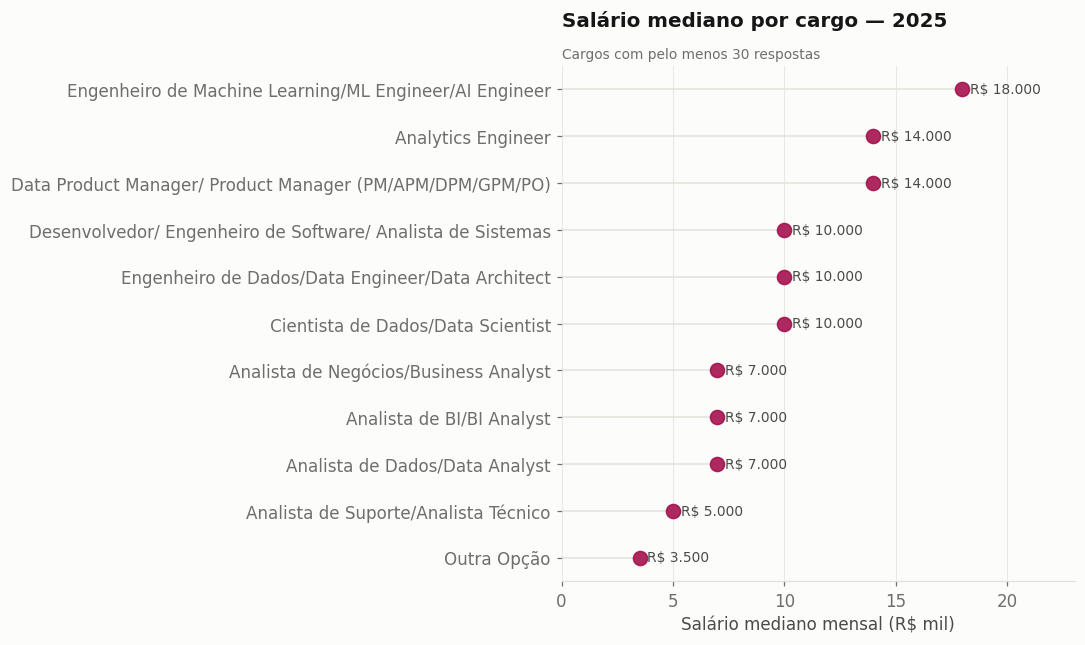

,mediana,n
cargo,,
Engenheiro de Machine Learning/ML Engineer/AI Engineer,18000.0,106
Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO),14000.0,33
Analytics Engineer,14000.0,135
Cientista de Dados/Data Scientist,10000.0,423
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas,10000.0,106
Engenheiro de Dados/Data Engineer/Data Architect,10000.0,402
Analista de Dados/Data Analyst,7000.0,599
Analista de BI/BI Analyst,7000.0,215


In [10]:
# Exemplo de gráfico: Salário mediano por cargo em 2025 (cargos com pelo menos 30 respostas).
salario_por_cargo = (
    df_2025_h.dropna(subset=["salario_ponto_medio"])
    .groupby("cargo")["salario_ponto_medio"]
    .agg(mediana="median", n="count")
    .query("n >= 30")
    .sort_values("mediana")
)

# Dot plot — salário mediano por cargo
fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(salario_por_cargo))

# Linhas-guia horizontais
ax.hlines(
    y=y,
    xmin=0,
    xmax=salario_por_cargo["mediana"],
    color=GRADE,
    linewidth=1.2,
    alpha=0.8,
    zorder=1
)

# Pontos
ax.scatter(
    salario_por_cargo["mediana"],
    y,
    s=85,
    color=COR_COMPARACAO,
    zorder=3
)

# Cargos no eixo Y
ax.set_yticks(y)
ax.set_yticklabels(
    salario_por_cargo.index,
    color=TINTA_MUTED
)

# Valores exatos ao lado dos pontos
for yi, valor in zip(y, salario_por_cargo["mediana"]):

    valor_formatado = f"R$ {valor:,.0f}".replace(",", ".")

    ax.text(
        valor + 350,
        yi,
        valor_formatado,
        va="center",
        ha="left",
        fontsize=9,
        color=TINTA_SECUNDARIA
    )

# Título e subtítulo
ax.set_title(
    "Salário mediano por cargo — 2025",
    loc="left",
    pad=26
)

ax.text(
    0,
    1.01,
    "Cargos com pelo menos 30 respostas",
    transform=ax.transAxes,
    fontsize=9,
    color=TINTA_MUTED,
    ha="left",
    va="bottom"
)

# Eixo X
ax.set_xticks([
    0,
    5000,
    10000,
    15000,
    20000
])

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x / 1000:.0f}"
    )
)

ax.set_xlabel("Salário mediano mensal (R$ mil)")
ax.set_ylabel("")

# Grade
ax.grid(
    axis="x",
    color=GRADE,
    linewidth=0.7,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="x",
    colors=TINTA_MUTED
)

ax.tick_params(
    axis="y",
    colors=TINTA_MUTED
)

# Limites
maior_salario = salario_por_cargo["mediana"].max()

ax.set_xlim(
    0,
    maior_salario * 1.28
)

# Limpeza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color(GRADE)

plt.tight_layout()
plt.show()


# Top 8 maiores salários medianos
salario_por_cargo.sort_values(
    "mediana",
    ascending=False
).head(8)

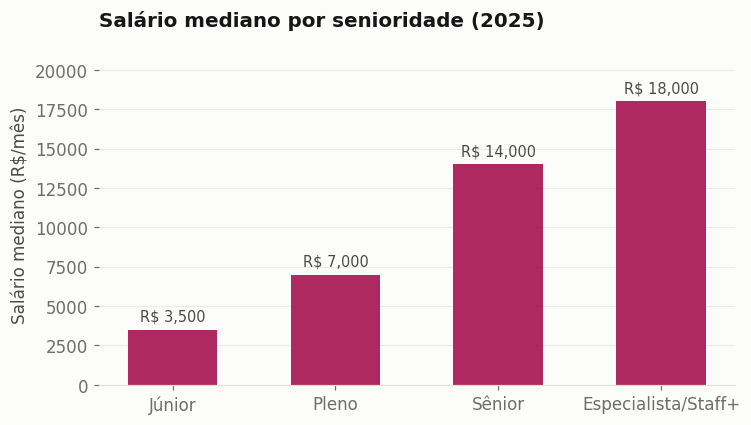

In [11]:
# Gráfico: Salário mediano por senioridade em 2025
salario_por_senioridade = (
    df_2025_h.dropna(subset=["salario_ponto_medio"])
    .groupby("senioridade")["salario_ponto_medio"].median()
    .reindex(SENIORIDADE_ORDEM).dropna()
)
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(salario_por_senioridade.index, salario_por_senioridade.values, color=COR_SEQUENCIAL, width=0.55)

# Adiciona os valores exatos acima das barras
ax.set_title("Salário mediano por senioridade (2025)", loc="left", pad=12)
ax.set_ylabel("Salário mediano (R$/mês)")
ax.grid(axis="y", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)
ymax = salario_por_senioridade.values.max()
ax.set_ylim(0, ymax * 1.2)
for barra, valor in zip(barras, salario_por_senioridade.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + ymax * 0.02, f"R$ {valor:,.0f}",
            ha="center", va="bottom", fontsize=9.5, color=TINTA_SECUNDARIA)

plt.tight_layout()
plt.show()

Entre os cargos com pelo menos 30 respostas em 2025, os maiores salários medianos aparecem em funções técnicas especializadas — Engenheiro de Machine Learning/AI Engineer e Analytics Engineer — e na função de produto Data Product Manager, e não necessariamente em cargos de liderança/gestão. Cargos de entrada e de suporte, como Analista de Suporte/Técnico e os papéis de Analista (Dados, BI, Negócios), aparecem entre os menores valores.

A senioridade também está associada ao salário: a mediana sobe de forma consistente de Júnior a Especialista/Staff+. Como essa última categoria só existe nos dados de 2025 (ver Pergunta 1), essa comparação é restrita a esse ano. O resultado é coerente com a leitura de que uma trajetória técnica avançada pode alcançar remuneração elevada mesmo sem exigir uma função de gestão, mas, por se tratar de dados de corte transversal (sem acompanhar as mesmas pessoas ao longo do tempo), não é possível afirmar causalidade entre especialização técnica e salário a partir apenas desta análise.

---
## Pergunta 3 - Qual é o cenário de diversidade de gênero nas carreiras de Dados?

Nesta parte, são analisados três pontos: a participação feminina ao longo dos anos, a participação por nível de senioridade em 2025 e a diferença salarial entre gêneros dentro de cada nível em 2025.

**Nota metodológica:** a evolução da participação feminina ao longo dos anos (gráfico abaixo) considera todas as respostas válidas da pergunta de gênero, incluindo as categorias "Outro" e "Prefiro não informar". Já a comparação por senioridade e o gap salarial restringem a base a Feminino e Masculino, por serem as duas categorias com volume suficiente para uma comparação direta; a linha de referência da "média geral 2025" no gráfico de senioridade foi recalculada sobre essa mesma base binária, para ficar comparável com as barras.

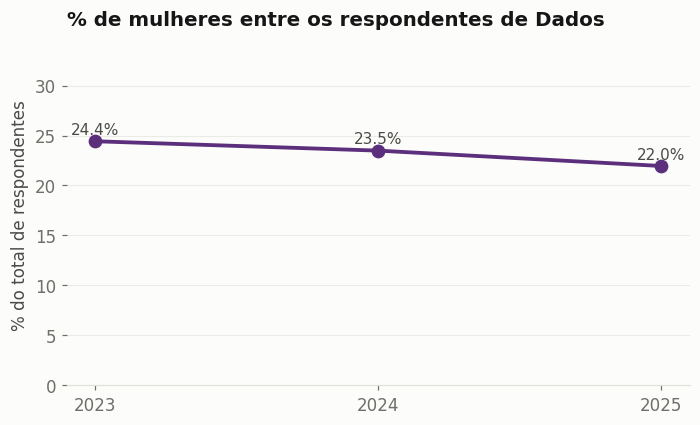

In [ ]:
# Gráfico: Percentual de mulheres entre os respondentes de Dados (2023 a 2025)
pct_genero_ano = pct_por_categoria(df.dropna(subset=["genero"]), "genero")
pct_feminino = pct_genero_ano.query("genero == 'Feminino'").set_index("ano_pesquisa")["pct"]

fig, ax = plt.subplots(figsize=(6.5, 4))

# Plota a linha do percentual de mulheres ao longo dos anos.
ax.plot(pct_feminino.index.astype(str), pct_feminino.values, marker="o", markersize=8,
        color=COR_DESTAQUE, linewidth=2.5)

# Adiciona os valores exatos acima dos pontos da linha.
for x, y in zip(pct_feminino.index.astype(str), pct_feminino.values):
    ax.text(x, y + 0.7, f"{y:.1f}%", ha="center", fontsize=10, color=TINTA_SECUNDARIA)

# Configurações do gráfico.    
ax.set_title("% de mulheres entre os respondentes de Dados", loc="left", pad=12)
ax.set_ylabel("% do total de respondentes")
ax.set_ylim(0, max(pct_feminino.values) * 1.4)
ax.grid(axis="y", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

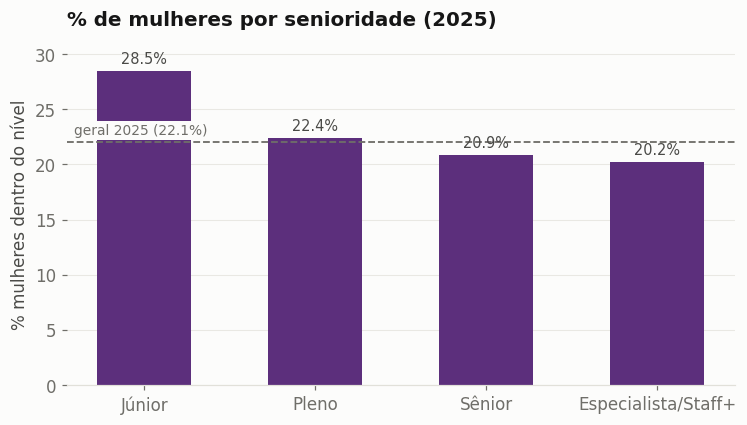

In [ ]:
# Gráfico: Percentual de mulheres por senioridade em 2025
pct_fem_senioridade = (
    df_2025_h[df_2025_h["genero"].isin(["Feminino", "Masculino"])]
    .groupby("senioridade")["genero"]
    .apply(lambda s: (s == "Feminino").mean() * 100)
    .reindex(SENIORIDADE_ORDEM)
    .dropna()
)

# Recalculada sobre a mesma base (Feminino/Masculino) usada nas barras acima, para ficar comparável com elas (ver nota metodológica no início da Pergunta 3).
# pct_feminino (todas as categorias de gênero) não é comparável diretamente com pct_fem_senioridade (apenas Feminino/Masculino).
base_2025_mf = df_2025_h[df_2025_h["genero"].isin(["Feminino", "Masculino"])]
media_2025 = (base_2025_mf["genero"] == "Feminino").mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))

barras = ax.bar(
    pct_fem_senioridade.index,
    pct_fem_senioridade.values,
    color=COR_DESTAQUE,
    width=0.55
)

# Adiciona uma linha para comparar com a média geral de 2025.
ax.axhline(
    media_2025,
    color=TINTA_MUTED,
    linestyle="--",
    linewidth=1.2,
    zorder=1
)

# Identifica o valor da média geral no gráfico.
ax.text(
    0.01,
    media_2025 + 0.35,
    f"geral 2025 ({media_2025:.1f}%)",
    transform=ax.get_yaxis_transform(),
    fontsize=9,
    color=TINTA_MUTED,
    ha="left",
    va="bottom",
    bbox=dict(
        facecolor=SUPERFICIE,
        edgecolor="none",
        pad=1.5
    ),
    zorder=3
)

# Adiciona o título, rótulo do eixo Y e grade.
ax.set_title(
    "% de mulheres por senioridade (2025)",
    loc="left",
    pad=12
)

# Adiciona o rótulo do eixo Y.
ax.set_ylabel(
    "% mulheres dentro do nível"
)

# Adiciona a grade horizontal.
ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.7,
    alpha=0.7
)

# Define que a grade deve ficar atrás das barras.
ax.set_axisbelow(True)

# Mostra o percentual acima de cada barra.
for barra, valor in zip(barras, pct_fem_senioridade.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.4,
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=TINTA_SECUNDARIA
    )

# Cria espaço para os valores acima das barras.
ax.set_ylim(
    0,
    pct_fem_senioridade.max() + 2.5
)

plt.tight_layout()
plt.show()

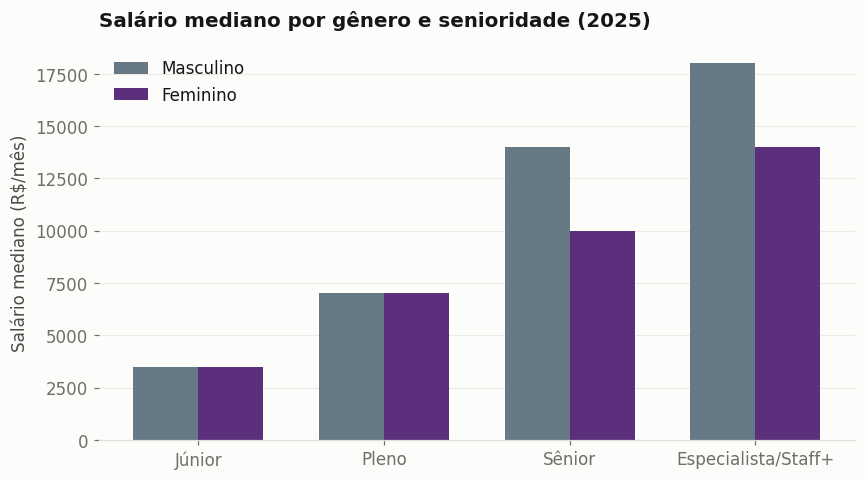

genero,Feminino,Masculino,gap_%
senioridade,,,
Júnior,3500.0,3500.0,0.0
Pleno,7000.0,7000.0,0.0
Sênior,10000.0,14000.0,29.0
Especialista/Staff+,14000.0,18000.0,22.0


In [ ]:
# Gráfico: Salário mediano por gênero e senioridade em 2025
gap_salarial = (
    df_2025_h[df_2025_h["genero"].isin(["Feminino", "Masculino"])]
    .dropna(subset=["salario_ponto_medio"])
    .groupby(["senioridade", "genero"])["salario_ponto_medio"].median()
    .unstack("genero").reindex(SENIORIDADE_ORDEM).dropna()
)
# O gap é calculado sobre a mediana do ponto médio das faixas salariais
# (aproximação — ver Pergunta 2), não sobre o salário exato de cada pessoa.
gap_salarial["gap_%"] = (1 - gap_salarial["Feminino"] / gap_salarial["Masculino"]) * 100

# Gráfico de barras lado a lado para comparar salários medianos por gênero e senioridade
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(gap_salarial))
largura = 0.35

# Plota as barras para cada gênero, deslocadas horizontalmente para ficarem lado a lado.
ax.bar(x - largura / 2, gap_salarial["Masculino"], width=largura, label="Masculino", color=COR_SEC_1)
ax.bar(x + largura / 2, gap_salarial["Feminino"], width=largura, label="Feminino", color=COR_DESTAQUE)
ax.set_xticks(x, gap_salarial.index)
ax.set_ylabel("Salário mediano (R$/mês)")
ax.set_title("Salário mediano por gênero e senioridade (2025)", loc="left", pad=12)
ax.grid(axis="y", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

gap_salarial.round(0)

A participação feminina entre os respondentes caiu de 24,4% em 2023 para 22,0% em 2025. Em 2025, considerando apenas Feminino e Masculino, a participação feminina também varia por senioridade, sendo menor entre Sênior e Especialista/Staff+ do que entre Júnior. Como 2023, 2024 e 2025 são amostras distintas e os grupos de diferentes senioridades são compostos por respondentes diferentes, não pelas mesmas pessoas acompanhadas ao longo do tempo (ver Limitações da análise), esse resultado é melhor descrito como um gradiente de representatividade por senioridade, com menor participação feminina nas categorias mais altas — e não como evidência de um funil de carreira que acompanhe as mesmas pessoas, nem como prova de causa entre senioridade e sub-representação feminina.

A comparação salarial mostra diferenças medianas entre homens e mulheres dentro de alguns níveis de senioridade em 2025, calculadas sobre o ponto médio das faixas salariais. Os resultados de Sênior e Especialista/Staff+ merecem atenção particular, mas — pelas mesmas razões — devem ser tratados como evidência descritiva da amostra, e não como relação causal estabelecida.

---
## Pergunta 4 - Quais tecnologias apresentam maior adoção entre os profissionais?

As tecnologias são organizadas de acordo com o percentual de uso em 2025. Em seguida, a adoção de AWS, Google Cloud e Azure é comparada entre os três anos.

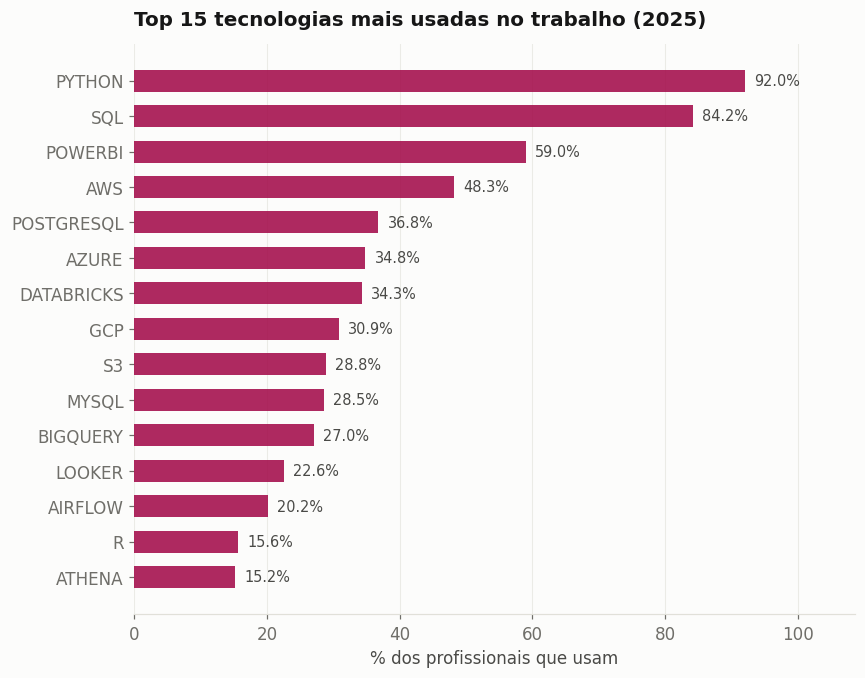

In [15]:
# Gráfico: Top 15 tecnologias mais usadas no trabalho em 2025
colunas_tec = [c for c in df.columns if c.startswith("usa_")]
NOMES_TEC = {c: c.replace("usa_", "").replace("_", " ").upper() for c in colunas_tec}

# Percentual calculado sobre respostas válidas (pct_sim); tecnologias não perguntadas
# em 2025 (ex.: Java, JavaScript) ficam inteiramente "N/I" nesse ano e são descartadas.
adocao_2025 = (
    df_2025_h[colunas_tec].apply(pct_sim)
    .rename(index=NOMES_TEC).dropna().sort_values(ascending=False).head(15)
)
barh_serie_unica(adocao_2025.sort_values(), "Top 15 tecnologias mais usadas no trabalho (2025)",
                  "% dos profissionais que usam", fmt="{:.1f}%")

plt.tight_layout()
plt.show()

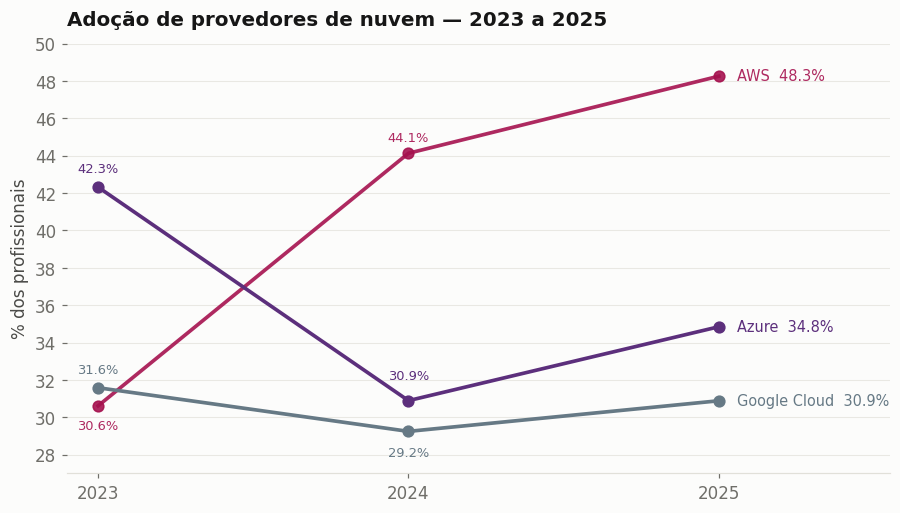

In [ ]:
# Gráfico: Adoção de provedores de nuvem - 2023 a 2025
clouds = {
    "usa_aws": "AWS",
    "usa_gcp": "Google Cloud",
    "usa_azure": "Azure"
}

adocao_cloud = (
    df.groupby("ano_pesquisa")[list(clouds)]
    .apply(pct_sim_colunas)
    .rename(columns=clouds)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Cores
cores_cloud = {
    "AWS": COR_COMPARACAO,      # magenta
    "Google Cloud": COR_SEC_1,  # cinza
    "Azure": COR_DESTAQUE       # lilás
}

# Deslocamentos dos rótulos
# Em pontos, para evitar sobreposição visual
offsets = {
    # 2023
    ("AWS", 2023): (0, -13),
    ("Google Cloud", 2023): (0, 12),
    ("Azure", 2023): (0, 12),

    # 2024
    ("AWS", 2024): (0, 10),
    ("Google Cloud", 2024): (0, -14),
    ("Azure", 2024): (0, 16),
}

anos = adocao_cloud.index.astype(int)

# Linhas
for cloud in clouds.values():
    valores = adocao_cloud[cloud]

    ax.plot(
        anos,
        valores,
        marker="o",
        markersize=7,
        linewidth=2.4,
        color=cores_cloud[cloud],
        zorder=3
    )

# Valores de 2023 e 2024
    for ano, valor in zip(anos[:-1], valores.iloc[:-1]):

        dx, dy = offsets[(cloud, ano)]

        ax.annotate(
            f"{valor:.1f}%",
            xy=(ano, valor),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=8.5,
            color=cores_cloud[cloud],
            zorder=5
        )

 # 2025: nome da série + valor em um único rótulo
    valor_final = valores.iloc[-1]

    ax.annotate(
        f"{cloud}  {valor_final:.1f}%",
        xy=(anos[-1], valor_final),
        xytext=(12, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="medium",
        color=cores_cloud[cloud],
        zorder=5
    )

# Título
ax.set_title(
    "Adoção de provedores de nuvem — 2023 a 2025",
    loc="left",
    pad=12
)

# Eixos
ax.set_ylabel("% dos profissionais")
ax.set_xlabel("")

ax.set_xticks(anos)

# Espaço extra à direita para os nomes das séries
ax.set_xlim(
    anos.min() - 0.1,
    anos.max() + 0.55
)

# Limites do eixo Y
# Ajustados à faixa real dos dados
menor_valor = adocao_cloud.min().min()
maior_valor = adocao_cloud.max().max()

limite_inferior = np.floor(menor_valor - 1.5)
limite_superior = np.ceil(maior_valor + 1.5)

ax.set_ylim(
    limite_inferior,
    limite_superior
)

# Ticks de 2 em 2 pontos percentuais
inicio_ticks = np.ceil(limite_inferior / 2) * 2

ax.set_yticks(
    np.arange(
        inicio_ticks,
        limite_superior + 0.1,
        2
    )
)

# Grade
ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.7,
    alpha=0.7
)

ax.set_axisbelow(True)

# Aparência
ax.tick_params(
    axis="both",
    colors=TINTA_MUTED
)

# Limpeza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRADE)

plt.tight_layout()
plt.show()

Python e SQL são, disparadamente, as tecnologias mais utilizadas entre os respondentes de 2025, seguidas por Power BI como ferramenta de BI mais citada.

Entre os provedores de nuvem, houve mudança de liderança ao longo do período: em 2023 a Azure era o provedor mais citado, à frente de Google Cloud e AWS; a partir de 2024 a AWS assumiu a liderança e ampliou a distância até 2025. Os percentuais de adoção também são mais altos do que em versões anteriores desta análise, pois passaram a excluir do cálculo quem não respondeu a essa seção da pesquisa (ver observação metodológica sobre perguntas binárias).

---
## Pergunta 5 - Qual é o nível de adoção de Inteligência Artificial e qual é o seu impacto?

A análise considera dois níveis de uso: o uso pessoal de ferramentas como ChatGPT e Copilot, e o uso de Inteligência Artificial pelas empresas.

As perguntas sobre uso pessoal e sobre impacto da IA no negócio são de múltipla escolha (o respondente pode marcar mais de uma opção) e, no caso do impacto no negócio, são exibidas apenas a quem já indicou alguma iniciativa de IA na empresa — por isso os percentuais são calculados sobre uma base menor e mais específica de respondentes (ver observação metodológica sobre perguntas binárias).

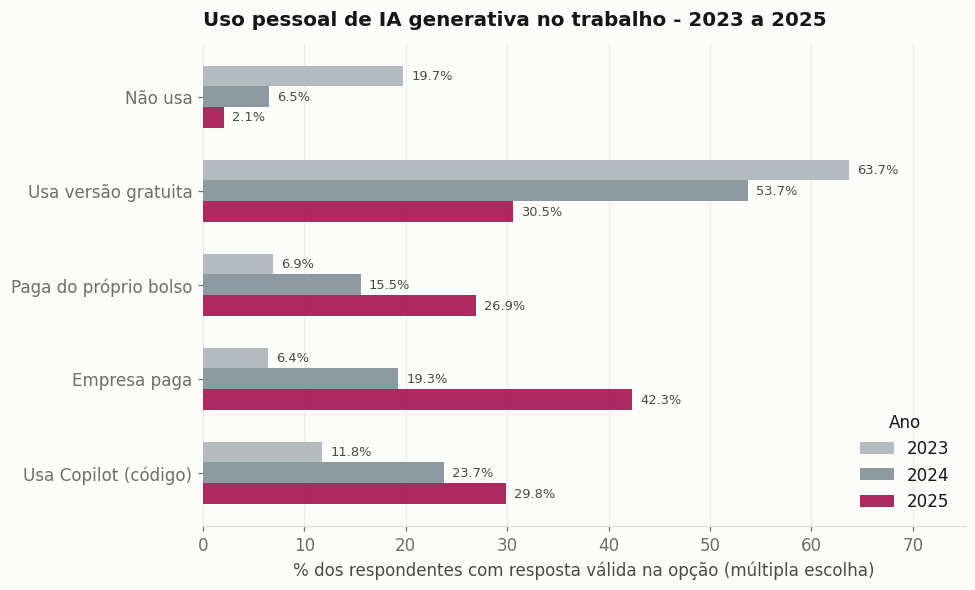

,Não usa,Usa versão gratuita,Paga do próprio bolso,Empresa paga,Usa Copilot (código)
ano_pesquisa,,,,,
2023,19.7,63.7,6.9,6.4,11.8
2024,6.5,53.7,15.5,19.3,23.7
2025,2.1,30.5,26.9,42.3,29.8


In [ ]:
# Gráfico: Uso pessoal de IA generativa no trabalho - 2023 a 2025
# Pergunta de múltipla escolha (o respondente pode marcar mais de uma opção), por isso as opções são comparadas lado a lado, e não empilhadas — uma barra
# empilhada sugeriria partes de um total, o que não é o caso aqui.
uso_pessoal_cols = {
    "ia_pessoal_nao_uso": "Não usa",
    "ia_pessoal_uso_gratuito": "Usa versão gratuita",
    "ia_pessoal_uso_pago_proprio": "Paga do próprio bolso",
    "ia_pessoal_empresa_paga": "Empresa paga",
    "ia_pessoal_uso_copilot": "Usa Copilot (código)",
}
uso_pessoal_ano = (
    df.groupby("ano_pesquisa")[list(uso_pessoal_cols)]
    .apply(pct_sim_colunas)
    .rename(columns=uso_pessoal_cols)
)

opcoes_uso_pessoal = list(uso_pessoal_cols.values())

fig, ax = plt.subplots(figsize=(9, 5.5))

altura = 0.22
y = np.arange(len(opcoes_uso_pessoal))

# Plota as barras para cada ano, deslocadas verticalmente para ficarem lado a lado.
for i, ano in enumerate(ANOS):

    valores = uso_pessoal_ano.loc[ano, opcoes_uso_pessoal].values

    barras = ax.barh(
        y + (i - 1) * altura,
        valores,
        height=altura,
        label=str(ano),
        color=COR_POR_ANO[ano]
    )

    # Valor ao final de cada barra
    for barra, valor in zip(barras, valores):
        ax.text(
            valor + 0.8,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=8.5,
            color=TINTA_SECUNDARIA
        )

# Configurações do gráfico
ax.set_yticks(y)
ax.set_yticklabels(opcoes_uso_pessoal)
ax.invert_yaxis()

ax.set_xlabel("% dos respondentes com resposta válida na opção (múltipla escolha)")
ax.set_ylabel("")
ax.set_title("Uso pessoal de IA generativa no trabalho - 2023 a 2025", loc="left", pad=12)

ax.grid(axis="x", linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)
ax.tick_params(axis="both", colors=TINTA_MUTED)

ax.legend(title="Ano", frameon=False, loc="lower right")

# Espaço extra à direita para os valores das barras
xmax = uso_pessoal_ano.values.max()
ax.set_xlim(0, xmax * 1.18)

plt.tight_layout()
plt.show()

uso_pessoal_ano.round(1)

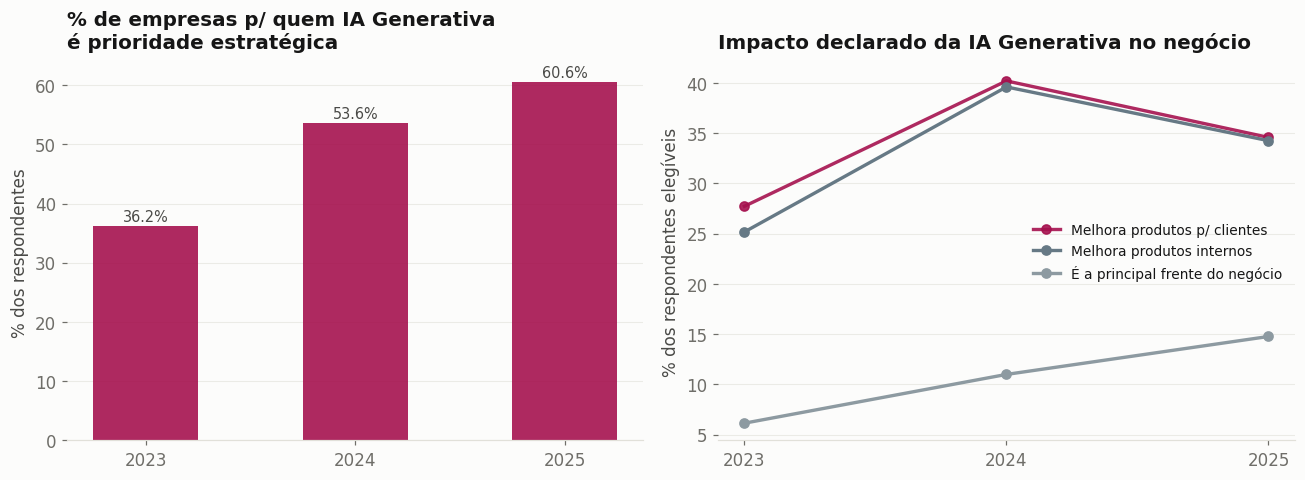

In [ ]:
# Gráfico: Percentual de empresas para quem IA Generativa é prioridade estratégica - 2023 a 2025
prioridade_sim = ["Sim, é nossa principal prioridade como empresa (com foco executivo significativo e alocação de orçamento relevante).",
                  "Sim, está entre nossas principais prioridades para os próximos 2-4 anos (com discussões de iniciativas e orçamentos de curto a médio prazo)."]

# Calcula o percentual de empresas para quem IA Generativa é prioridade estratégica.
pct_prioridade = (
    df.dropna(subset=["ia_prioridade"])
    .groupby("ano_pesquisa")["ia_prioridade"]
    .apply(lambda s: s.isin(prioridade_sim).mean() * 100)
)
impacto_cols = {
    "ia_uso_produtos_externos": "Melhora produtos p/ clientes",
    "ia_uso_produtos_internos": "Melhora produtos internos",
    "ia_uso_principal_frente_negocio": "É a principal frente do negócio",
}
# Esta pergunta só é exibida a quem já indicou alguma iniciativa de IA na empresa, por isso a base de respostas válidas é bem menor que o total de respondentes do
# ano (ver observação metodológica sobre perguntas binárias e condicionais).
impacto_ano = df.groupby("ano_pesquisa")[list(impacto_cols)].apply(pct_sim_colunas).rename(columns=impacto_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico de barras para o percentual de empresas para quem IA Generativa é prioridade estratégica
axes[0].bar(pct_prioridade.index.astype(str), pct_prioridade.values, color=COR_SEQUENCIAL, width=0.5)
axes[0].set_title("% de empresas p/ quem IA Generativa\né prioridade estratégica", loc="left", pad=10)
axes[0].set_ylabel("% dos respondentes")
axes[0].grid(axis="y", linewidth=0.7, alpha=0.6); axes[0].set_axisbelow(True)

# Adiciona os valores percentuais acima das barras
for x, y in zip(pct_prioridade.index.astype(str), pct_prioridade.values):
    axes[0].text(x, y + 0.8, f"{y:.1f}%", ha="center", fontsize=9.5, color=TINTA_SECUNDARIA)

for i, col in enumerate(impacto_cols.values()):
    axes[1].plot(impacto_ano.index.astype(str), impacto_ano[col], marker="o", label=col,
                 color=PALETA_CATEGORICA[i], linewidth=2.2)

# Adiciona os valores percentuais acima dos pontos
axes[1].set_title("Impacto declarado da IA Generativa no negócio", loc="left", pad=10)
axes[1].set_ylabel("% dos respondentes elegíveis")
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(axis="y", linewidth=0.7, alpha=0.6); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

O uso pessoal de Inteligência Artificial Generativa cresceu de forma acentuada entre 2023 e 2025: a parcela que declara não usar caiu de cerca de 20% para 2%, o uso pago pela empresa saltou de 6% para 42%, e o uso de ferramentas do tipo Copilot mais que dobrou, de 12% para cerca de 30%. Como a pergunta é de múltipla escolha, essas opções não somam 100% em nenhum ano — por isso são comparadas lado a lado, e não empilhadas.

A pergunta sobre o impacto da IA Generativa no negócio só é exibida a quem já indicou alguma iniciativa de IA na empresa — uma base bem menor que o total de respondentes (entre aproximadamente 600 e 1.000 pessoas por ano). Dentro dessa base mais específica, a parcela que relata melhoria em produtos para clientes ou em produtos internos ficou entre um quarto e 40% nos três anos, e a parcela que considera a IA a principal frente do negócio cresceu de forma consistente, de cerca de 6% para 15%. Combinados, os dois resultados sugerem que o uso pessoal de IA se popularizou mais rapidamente do que sua transformação em iniciativas estruturadas de impacto no negócio — leitura válida para quem já está engajado com IA na empresa, e não necessariamente para o mercado como um todo.

---
## Pergunta 6 - Existem diferenças entre regiões, senioridades ou modelos de trabalho?

Nesta etapa, são comparados o salário por região, a distribuição dos modelos de trabalho ao longo dos anos e a adoção de tecnologias avançadas por senioridade.

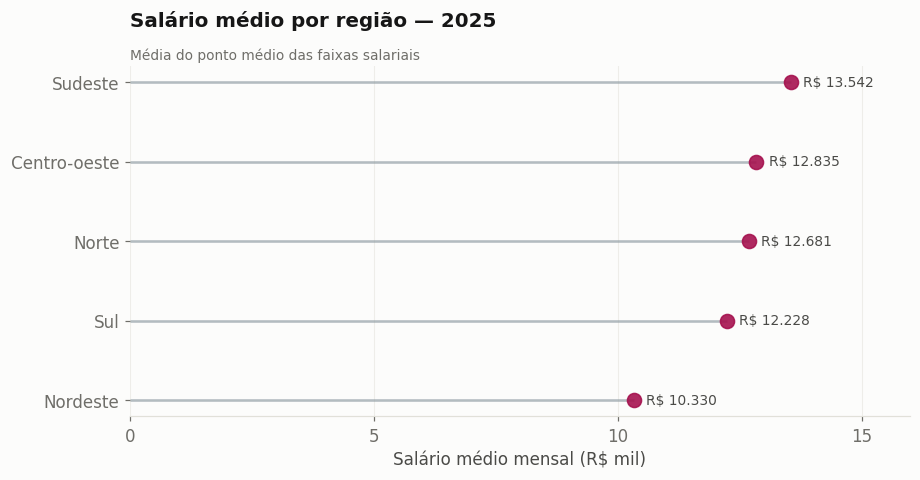

Respostas válidas por região: {'Centro-oeste': 221, 'Nordeste': 329, 'Norte': 36, 'Sudeste': 2024, 'Sul': 510}


In [19]:
# Gráfico: Salário médio por região em 2025
dados_salario_regiao = df_2025_h.dropna(
    subset=["salario_ponto_medio", "regiao"]
)

contagem_regiao = (
    dados_salario_regiao
    .groupby("regiao")
    .size()
)

salario_por_regiao = (
    dados_salario_regiao
    .groupby("regiao")["salario_ponto_medio"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))

y = np.arange(len(salario_por_regiao))

ax.hlines(
    y=y,
    xmin=0,
    xmax=salario_por_regiao.values,
    color=COR_SEC_2,
    linewidth=1.7,
    alpha=0.65,
    zorder=1
)

ax.scatter(
    salario_por_regiao.values,
    y,
    s=85,
    color=COR_COMPARACAO,
    zorder=3
)

ax.set_yticks(y)
ax.set_yticklabels(
    salario_por_regiao.index,
    color=TINTA_MUTED
)

for yi, valor in zip(y, salario_por_regiao.values):
    valor_formatado = f"R$ {valor:,.0f}".replace(",", ".")

    ax.annotate(
        valor_formatado,
        xy=(valor, yi),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        color=TINTA_SECUNDARIA,
        zorder=5
    )

ax.set_title(
    "Salário médio por região — 2025",
    loc="left",
    pad=26
)

ax.text(
    0,
    1.01,
    "Média do ponto médio das faixas salariais",
    transform=ax.transAxes,
    fontsize=9,
    color=TINTA_MUTED,
    ha="left",
    va="bottom"
)

ax.set_xticks([0, 5000, 10000, 15000])

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1000:.0f}")
)

ax.set_xlabel("Salário médio mensal (R$ mil)")
ax.set_ylabel("")

maior_salario = salario_por_regiao.max()

ax.set_xlim(
    0,
    max(15000, maior_salario * 1.18)
)

ax.grid(
    axis="x",
    color=GRADE,
    linewidth=0.7,
    alpha=0.5
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    colors=TINTA_MUTED
)

# Limpeza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRADE)

plt.tight_layout()
plt.show()

print(
    "Respostas válidas por região:",
    contagem_regiao.to_dict()
)

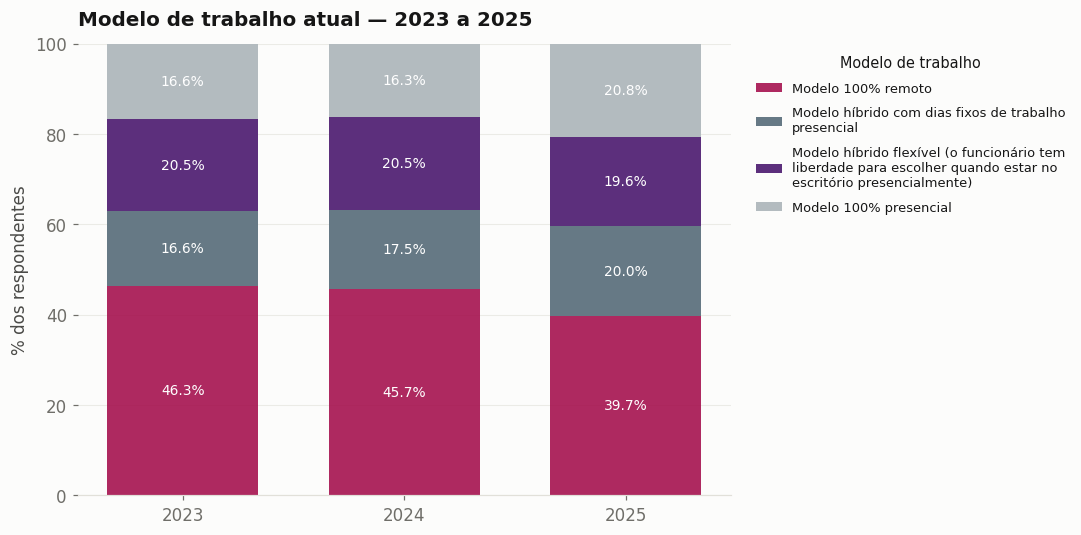

In [20]:
# Gráfico: Modelo de trabalho atual — 2023 a 2025
modelo_ano = pct_por_categoria(
    df.dropna(subset=["modelo_trabalho"]),
    "modelo_trabalho"
)

modelos = modelo_ano["modelo_trabalho"].unique().tolist()

# Do mais remoto para o mais presencial
ordem_modelo = sorted(
    modelos,
    key=lambda m: (
        "remoto" not in m.lower(),
        "híbrido" not in m.lower(),
        m
    )
)

def cor_modelo(modelo):
    texto = modelo.lower()

    if "100% remoto" in texto:
        return COR_COMPARACAO

    if "híbrido" in texto and "flex" in texto:
        return COR_DESTAQUE

    if "híbrido" in texto:
        return COR_SEC_1

    return COR_SEC_3

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(ANOS))

for modelo in ordem_modelo:

    valores = [
        modelo_ano.query(
            "ano_pesquisa == @ano and modelo_trabalho == @modelo"
        )["pct"].sum()
        for ano in ANOS
    ]

    barras = ax.bar(
        [str(a) for a in ANOS],
        valores,
        bottom=bottom,
        width=0.68,
        color=cor_modelo(modelo),
        label=textwrap.fill(modelo, width=42)
    )

    # Percentuais dentro das faixas
    for i, (barra, valor) in enumerate(zip(barras, valores)):

        if valor >= 6:
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                bottom[i] + valor / 2,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="medium",
                color="white" if valor >= 12 else TINTA_PRIMARIA
            )

    bottom += np.array(valores)

ax.set_title(
    "Modelo de trabalho atual — 2023 a 2025",
    loc="left",
    pad=12
)

ax.set_ylabel("% dos respondentes")
ax.set_xlabel("")

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.7,
    alpha=0.6
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    colors=TINTA_MUTED
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRADE)

ax.legend(
    title="Modelo de trabalho",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=8.5,
    title_fontsize=9.5,
    labelspacing=0.9
)

plt.tight_layout()
plt.show()

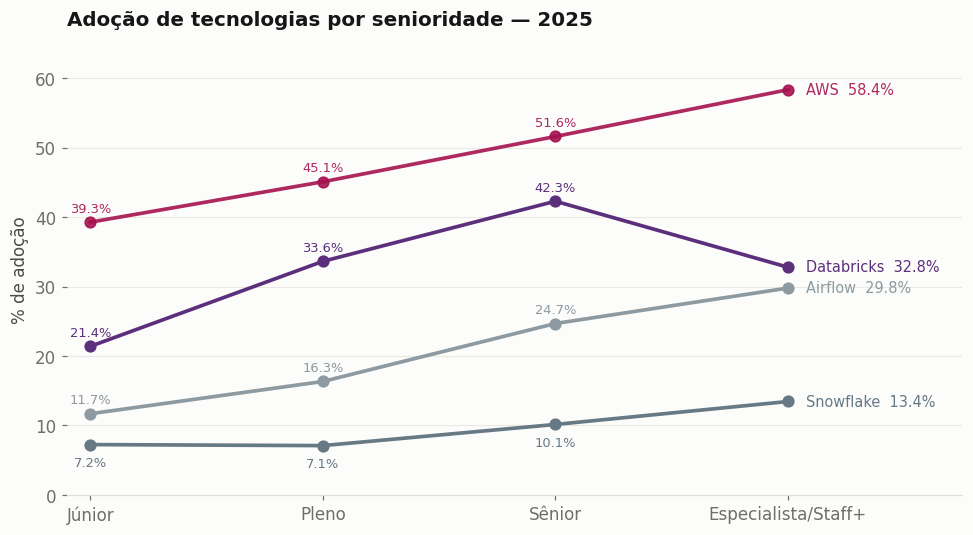

In [21]:
# Gráfico: Adoção de tecnologias avançadas por senioridade em 2025
tecnologias_avancadas = [
    "usa_databricks",
    "usa_snowflake",
    "usa_airflow",
    "usa_aws"
]

adocao_por_senioridade = (
    df_2025_h.groupby("senioridade")[tecnologias_avancadas]
    .apply(pct_sim_colunas)
    .reindex(SENIORIDADE_ORDEM)
    .dropna()
    .rename(columns=lambda c: c.replace("usa_", "").upper())
)

cores_tecnologia = {
    "AWS": COR_COMPARACAO,
    "DATABRICKS": COR_DESTAQUE,
    "SNOWFLAKE": COR_SEC_1,
    "AIRFLOW": COR_SEC_2
}

nomes_tecnologia = {
    "AWS": "AWS",
    "DATABRICKS": "Databricks",
    "SNOWFLAKE": "Snowflake",
    "AIRFLOW": "Airflow"
}

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(adocao_por_senioridade.index))

offsets = {
    "AWS": 9,
    "DATABRICKS": 9,
    "SNOWFLAKE": -12,
    "AIRFLOW": 9
}

# Linhas de cada tecnologia
for tecnologia in adocao_por_senioridade.columns:
    valores = adocao_por_senioridade[tecnologia]

    ax.plot(
        x,
        valores,
        marker="o",
        markersize=7,
        linewidth=2.4,
        color=cores_tecnologia[tecnologia],
        zorder=3
    )

    for xi, valor in zip(x[:-1], valores.iloc[:-1]):
        ax.annotate(
            f"{valor:.1f}%",
            xy=(xi, valor),
            xytext=(0, offsets[tecnologia]),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=8.5,
            color=cores_tecnologia[tecnologia],
            zorder=5
        )

    valor_final = valores.iloc[-1]

    ax.annotate(
        f"{nomes_tecnologia[tecnologia]}  {valor_final:.1f}%",
        xy=(x[-1], valor_final),
        xytext=(12, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="medium",
        color=cores_tecnologia[tecnologia],
        zorder=5
    )

# Título e eixos
ax.set_title(
    "Adoção de tecnologias por senioridade — 2025",
    loc="left",
    pad=12
)

ax.set_ylabel("% de adoção")
ax.set_xlabel("")

ax.set_xticks(x)
ax.set_xticklabels(adocao_por_senioridade.index)

ax.set_xlim(
    -0.1,
    len(x) - 1 + 0.75
)

ax.set_ylim(0, 65)
ax.set_yticks(np.arange(0, 66, 10))

ax.grid(
    axis="y",
    color=GRADE,
    linewidth=0.7,
    alpha=0.7
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    colors=TINTA_MUTED
)

# Limpeza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRADE)

plt.tight_layout()
plt.show()

Existem diferenças regionais nos salários médios de 2025: a região Sudeste apresenta a maior média, enquanto o Nordeste apresenta a menor. A região Norte tem apenas 36 respostas válidas — muito menos que o Sudeste (2.024) —, por isso seu resultado deve ser interpretado com cautela e não tratado como representativo da região.

O trabalho 100% remoto perdeu participação entre 2023 e 2025 (de 46,3% para 39,7%), enquanto o modelo 100% presencial ganhou espaço de forma mais clara (de 16,6% para 20,8%). Entre os modelos híbridos, o de dias fixos também cresceu (de 16,6% para 20,0%), enquanto o híbrido flexível permaneceu praticamente estável.

Em 2025, a adoção de tecnologias avançadas cresce com a senioridade para Snowflake, Airflow e AWS, sugerindo espaço para capacitar profissionais Júnior e Pleno nessas ferramentas. O Databricks é uma exceção parcial: a adoção sobe até o nível Sênior e cai entre os Especialistas/Staff+, o que pode refletir diferenças de stack tecnológico por tipo de função nesse grupo — mais avançado tecnicamente, porém mais heterogêneo — e não necessariamente um menor domínio da ferramenta.

---
## Pergunta 7 - Quais oportunidades e desafios existem para empresas que desejam investir em Dados e Inteligência Artificial?

Para concluir, são analisados os principais motivos para não adotar IA generativa e a evolução do tamanho das equipes de Dados.

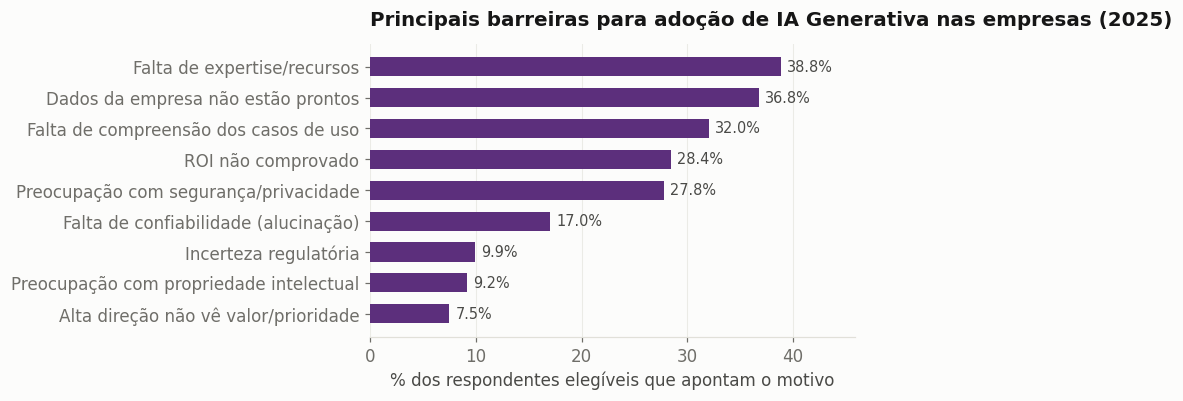

In [ ]:
# Gráfico: Principais barreiras para adoção de IA Generativa nas empresas (2025).
# As perguntas sobre barreiras para adoção de IA Generativa foram feitas apenas em 2025, e apenas para quem ainda não usa (ou usa pouco) 
# IA Generativa na empresa — uma base menor que o total de respondentes de 2025 (ver observação metodológica).
motivos_cols = [c for c in df.columns if c.startswith("ia_motivo_")]
NOMES_MOTIVOS = {
    "ia_motivo_falta_compreensao": "Falta de compreensão dos casos de uso",
    "ia_motivo_falta_confiabilidade": "Falta de confiabilidade (alucinação)",
    "ia_motivo_incerteza_regulacao": "Incerteza regulatória",
    "ia_motivo_seguranca_privacidade": "Preocupação com segurança/privacidade",
    "ia_motivo_roi_nao_comprovado": "ROI não comprovado",
    "ia_motivo_dados_nao_prontos": "Dados da empresa não estão prontos",
    "ia_motivo_falta_expertise": "Falta de expertise/recursos",
    "ia_motivo_alta_direcao_nao_ve_valor": "Alta direção não vê valor/prioridade",
    "ia_motivo_propriedade_intelectual": "Preocupação com propriedade intelectual",
}
motivos_2025 = (
    df_2025_h[motivos_cols].apply(pct_sim)
    .rename(index=NOMES_MOTIVOS).sort_values()
)
barh_serie_unica(motivos_2025, "Principais barreiras para adoção de IA Generativa nas empresas (2025)",
                  "% dos respondentes elegíveis que apontam o motivo", cor=COR_DESTAQUE, fmt="{:.1f}%")

plt.tight_layout()
plt.show()

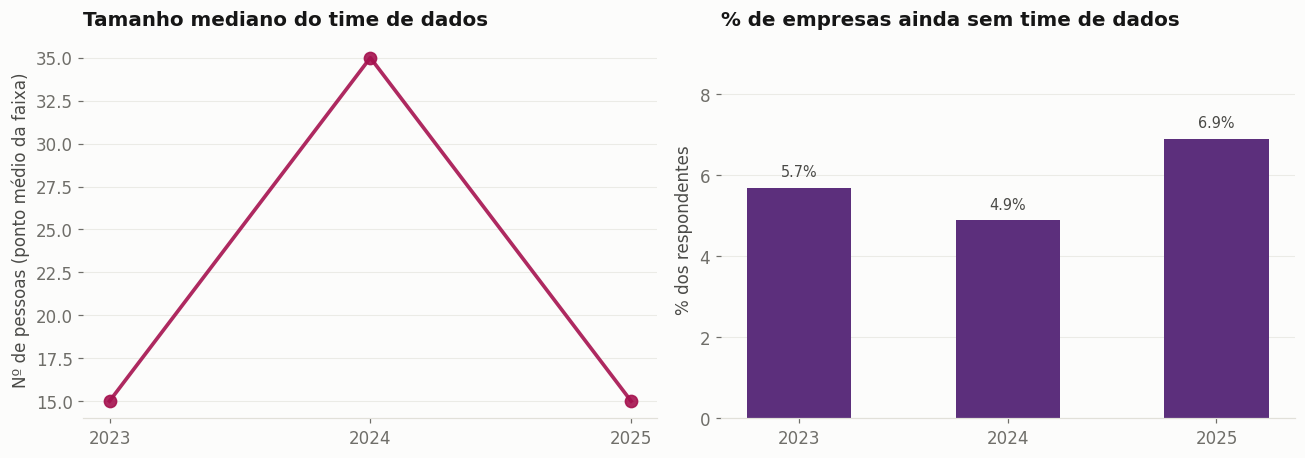

respostas validas sobre tamanho de time, por ano: {2023: 896, 2024: 1045, 2025: 652}


In [23]:
# Gráfico: Tamanho do time de dados e % de empresas sem time de dados — 2023 a 2025
tamanho_medio_ano = df.groupby("ano_pesquisa")["tamanho_time_ponto_medio"].median()
pct_sem_time = (
    df.dropna(subset=["numero_pessoas_dados"])
    .groupby("ano_pesquisa")["numero_pessoas_dados"]
    .apply(lambda s: (s == "Ainda não temos pessoas atuando com dados na empresa").mean() * 100)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# Gráfico de linha para o tamanho mediano do time de dados
axes[0].plot(tamanho_medio_ano.index.astype(str), tamanho_medio_ano.values, marker="o",
             color=COR_SEQUENCIAL, linewidth=2.4, markersize=8)
axes[0].set_title("Tamanho mediano do time de dados", loc="left", pad=10)
axes[0].set_ylabel("Nº de pessoas (ponto médio da faixa)")
axes[0].grid(axis="y", linewidth=0.7, alpha=0.6); axes[0].set_axisbelow(True)

# Adiciona os valores exatos acima dos pontos
axes[1].bar(pct_sem_time.index.astype(str), pct_sem_time.values, color=COR_DESTAQUE, width=0.5)
axes[1].set_title("% de empresas ainda sem time de dados", loc="left", pad=10)
axes[1].set_ylabel("% dos respondentes")
axes[1].set_ylim(0, pct_sem_time.values.max() * 1.35)
axes[1].grid(axis="y", linewidth=0.7, alpha=0.6); axes[1].set_axisbelow(True)

# Adiciona os valores percentuais acima das barras
for x, y in zip(pct_sem_time.index.astype(str), pct_sem_time.values):
    axes[1].text(x, y + pct_sem_time.values.max() * 0.04, f"{y:.1f}%", ha="center", fontsize=9.5, color=TINTA_SECUNDARIA)

plt.tight_layout()
plt.show()

print("respostas validas sobre tamanho de time, por ano:", df.groupby("ano_pesquisa")["numero_pessoas_dados"].count().to_dict())

**Desafios:** esta pergunta é exibida apenas a quem ainda não usa (ou usa pouco) IA Generativa na empresa — uma base de 587 respondentes em 2025, bem menor que o total da amostra daquele ano. Dentro dessa base, as barreiras mais citadas são a falta de expertise/recursos (38,8%) e os dados da empresa não estarem prontos (36,8%), seguidas pela falta de compreensão dos casos de uso (32,0%), ROI não comprovado (28,4%) e preocupações com segurança/privacidade (27,8%). Motivos regulatórios, de propriedade intelectual e de patrocínio da alta direção aparecem com menor frequência nesta amostra. Como a pergunta não existiu nas edições de 2023 e 2024, não é possível afirmar se essas barreiras mudaram ao longo do tempo — o retrato é específico de 2025.

Os resultados reforçam que a preparação dos dados (qualidade, governança e organização) e a capacitação técnica das equipes são pré-condições relevantes, observadas nesta amostra, antes de ampliar projetos de IA — sem que isso implique que resolvê-las seja suficiente para garantir adoção bem-sucedida.

**Oportunidades:** o tamanho mediano das equipes de Dados varia entre os anos (15, 35 e 15 pessoas em 2023, 2024 e 2025, respectivamente) e é calculado sobre uma fração pequena da amostra em cada ano (entre 652 e 1.045 respostas, de um total de milhares) — por isso essa série deve ser interpretada com cautela, sem inferir uma tendência. A grande maioria das empresas que respondeu à pergunta já possui alguma estrutura de Dados: a parcela sem nenhuma pessoa dedicada ficou entre 4,9% e 6,9% ao longo dos anos.

Combinadas com as demais perguntas deste notebook, as evidências apontam para oportunidades concentradas em três frentes: elevar a maturidade e a governança dos dados, capacitar profissionais Júnior e Pleno nas tecnologias mais avançadas (Pergunta 6) e transformar o uso pessoal já disseminado de IA (Pergunta 5) em iniciativas de negócio estruturadas — hoje reportadas por apenas uma parcela das empresas já engajadas com o tema.

---
## Limitações da análise

Antes da conclusão, iremos explicitar os principais limites metodológicos das análises anteriores:

- **Os resultados descrevem os respondentes da pesquisa, não o mercado como um todo.** Os dados analisados não constituem, neste trabalho, uma amostra probabilística do mercado brasileiro de Dados. Portanto, os resultados devem ser interpretados como características dos respondentes da pesquisa, e não como estimativas populacionais do mercado como um todo.
  
- **Os três anos não formam um painel longitudinal.** 2023, 2024 e 2025 são amostras distintas, sem garantia de que os mesmos profissionais responderam em mais de uma edição. Variações entre anos podem refletir mudanças reais no mercado, mas também mudanças em quem respondeu à pesquisa em cada ano.
  
- **Os salários são faixas, não valores exatos.** Todas as análises salariais usam o ponto médio da faixa informada como aproximação, o que é especialmente impreciso na faixa aberta "Acima de R$ 40.001/mês" (ver Pergunta 2).
  
- **O tamanho das equipes também é informado em faixas.** Para algumas análises, cada faixa foi substituída por um valor representativo (por exemplo, "1 - 3" pessoas → 2, "Acima de 300 pessoas" → 350), de forma análoga ao tratamento salarial. Portanto, as medianas de `tamanho_time_ponto_medio` apresentadas devem ser interpretadas como aproximações, e não como o número exato de profissionais das equipes.
  
- **Algumas perguntas têm amostras menores ou mudam entre os anos.** Perguntas condicionais (por exemplo, os motivos para não usar IA Generativa e o impacto da IA no negócio) só são exibidas a um subconjunto de respondentes; a pergunta sobre motivos de não adoção de IA só existiu em 2025; e o tamanho do time de dados tem uma fração pequena de respostas em todos os anos. Cada uma dessas restrições foi indicada no texto da seção correspondente.
  
- **Diferenças observadas não implicam causalidade.** Associações entre senioridade, gênero, tecnologia e salário são descritivas. Não há controle por outras variáveis (por exemplo, setor, região, tempo de empresa), então nenhuma dessas relações deve ser lida como efeito causal.

---
## Conclusão

Ao reunir três edições da pesquisa State of Data Brasil, este notebook traça um retrato do mercado brasileiro de Dados entre 2023 e 2025 — sempre com a ressalva de que se trata de um retrato da amostra de respondentes, não do mercado como um todo (ver Limitações da análise).

**Estrutura do mercado.** O mercado está concentrado em Finanças/Bancos e Tecnologia, mas o tamanho das equipes de Dados é heterogêneo: não há uma faixa dominante, e a participação de equipes grandes oscila entre os anos, sem tendência clara de crescimento. A distribuição por senioridade é estável, com maioria de profissionais Plenos e Sêniores.

**Valorização de especialização e senioridade.** Os maiores salários medianos aparecem menos em cargos de liderança do que em funções técnicas especializadas (Machine Learning Engineer, Analytics Engineer) e em produto (Data Product Manager). A senioridade também acompanha o salário de forma consistente, e a categoria Especialista/Staff+ — que só passou a existir na pesquisa em 2025 — reforça que uma trajetória técnica avançada pode alcançar remuneração elevada mesmo sem exigir uma função de gestão.

**Diversidade de gênero.** A participação feminina caiu de 24,4% para 22,0% dos respondentes entre 2023 e 2025 e é menor nos níveis de maior senioridade. Soma-se a isso um gap salarial mediano entre homens e mulheres dentro de alguns níveis. Juntos, representatividade e remuneração são compatíveis com um desafio de diversidade que se manifesta de forma mais acentuada nos níveis de maior senioridade — um gradiente observado entre grupos diferentes de respondentes nesta amostra, e não uma relação causal ou uma trajetória acompanhada ao longo do tempo.

**Tecnologias predominantes.** Python, SQL e Power BI dominam o dia a dia dos profissionais. Entre provedores de nuvem, a AWS assumiu a liderança a partir de 2024, superando a Azure, que liderava em 2023. A adoção de tecnologias mais avançadas (Databricks, Snowflake, Airflow) cresce com a senioridade, com a exceção parcial do Databricks entre os Especialistas/Staff+.

**Avanço da IA.** O uso pessoal de IA Generativa se popularizou rapidamente: a parcela de profissionais que não usa nenhuma ferramenta caiu de cerca de 20% para 2% em três anos. Já a transformação desse uso em iniciativas estruturadas de negócio avança em ritmo mais lento e concentrado em empresas que já têm alguma iniciativa de IA — sinal de que o avanço individual está à frente da maturidade organizacional.

**Diferenças regionais, de senioridade e de modelo de trabalho.** Os salários médios variam por região (maiores no Sudeste, menores no Nordeste), com a ressalva de que o Norte tem poucas respostas válidas. O modelo de trabalho migrou do 100% remoto para presencial e híbrido com dias fixos entre 2023 e 2025. A adoção de tecnologias avançadas segue, de forma geral, a senioridade.

**Oportunidades e desafios.** As principais barreiras à adoção de IA Generativa, entre quem ainda não a usa amplamente, são a falta de expertise/recursos e a falta de preparo dos dados da empresa — reforçando que maturidade de dados e capacitação técnica são pré-condições observadas nesta amostra para avançar em projetos de IA.

Em conjunto, essas sete perguntas apontam para uma mesma direção: o avanço sustentável em Dados e Inteligência Artificial no Brasil não depende apenas de ferramentas ou de entusiasmo individual, mas da combinação de pessoas qualificadas, dados confiáveis, governança e casos de uso capazes de gerar valor real para o negócio.